# I. Etude du problème d'optimisation

1.  Interpréter la définition de l’énergie auto-consommée. 

Pour calculer l'énergie autoconsommée, on fait la somme sur les différents intervalles de temps. Sur chaque intervalle, on prend le minimum entre l'énergie photovoltaïque produite par les panneaux et la somme  de la consommation non-pilotables et de l'énergie produite par chauffage.

En effet, si on $ E^{PV}_i < w_i + P_i \Delta t $, cela signifie que l'on produit moins que ce que l'on consomme. On va donc auto-consommer tout ce que l'on produit, donc le min. A l'inverse, si  $E^{PV}_i > w_i + P_i \Delta t $, cela signifie que l'on produit plus d'énergie que nécessaire. On va donc seulement consommer $w_i + P_i \Delta t $. 


De manière équivalente, dans la deuxième somme : on choisit le minimum entre l'énergie produite à laquelle on a soustrait l'énergie non-pilotable (on considère le surplus solaire après avoir satisfait les consommations non-pilotables)  et l'énergie pilotable dont on a besoin

La fonction min est convexe mais non différentiable en $P_i \Delta t=E_i P_i$
​, ce qui rend l'optimisation directe difficile (pas de gradient partout). C'est un problème de programmation convexe non lisse.
 


2.  En lieu et place de (4), on se propose de maximiser la fonction dite de "soft-min" $h$ ci-dessous, avec $α > 0$ constante. Justifier que, pour $α$ grand, $h$ est une bonne approximation de la fonction min.
Quel intérêt a-t-on alors à considérer ce problème approché plutôt que le problème original

Soient $x_1, x_2 \in \mathbb{R}$. On a :

$$h(x_1, x_2) = \frac{x_1 e^{-\alpha x_1} + x_2 e^{-\alpha x_2}}{e^{-\alpha x_1} + e^{-\alpha x_2}}$$

Sans perte de généralité, supposons $x_1 \leq x_2$, de sorte que $\min(x_1, x_2) = x_1$.


On factorise par $e^{-\alpha x_1}$ au numérateur et au dénominateur :

$$h(x_1, x_2) = \frac{e^{-\alpha x_1}\left(x_1 + x_2\, e^{-\alpha(x_2 - x_1)}\right)}{e^{-\alpha x_1}\left(1 + e^{-\alpha(x_2 - x_1)}\right)} = \frac{x_1 + x_2\, e^{-\alpha(x_2 - x_1)}}{1 + e^{-\alpha(x_2 - x_1)}}$$

Posons $\delta = x_2 - x_1 \geq 0$, ce qui donne :

$$h(x_1, x_2) = \frac{x_1 + x_2\, e^{-\alpha \delta}}{1 + e^{-\alpha \delta}}$$


**Cas 1 :** $\delta > 0$ (i.e. $x_1 < x_2$). Alors $e^{-\alpha \delta} \to 0$, donc :

$$h(x_1, x_2) \;\longrightarrow\; \frac{x_1 + 0}{1 + 0} = x_1 = \min(x_1, x_2)$$

**Cas 2 :** $\delta = 0$ (i.e. $x_1 = x_2$). Alors :

$$h(x_1, x_2) = \frac{x_1 + x_1}{1 + 1} = x_1 = \min(x_1, x_2)$$

Dans les deux cas :

$$\boxed{h(x_1, x_2) \;\xrightarrow[\alpha \to +\infty]{}\; \min(x_1, x_2)}$$


Pour $\delta > 0$ fixé, l'erreur d'approximation vaut :

$$h(x_1, x_2) - \min(x_1, x_2) = \frac{x_1 + x_2\,e^{-\alpha\delta}}{1 + e^{-\alpha\delta}} - x_1 = \frac{\delta\, e^{-\alpha\delta}}{1 + e^{-\alpha\delta}}$$

Cette quantité est **positive** et tend vers $0$ **exponentiellement vite** quand $\alpha \to +\infty$.




$h$ est une fonction $C^\infty$  pour $\alpha > 0$, ce qui permet d'utiliser des algorithmes de gradient (descente de gradient, L-BFGS, etc.): on peut donc appliquer les résultats d'optmisation vus en cours. 

3. Interpréter l’équation (1). Cette modélisation vous semble-t-elle raisonnable ?

L'équation (1) est une discrétisation du problème. 

La température à l'instant $t+1$ est égale à la température à l'instant $t$ multipliée par la perte de chaleur, à laquelle on ajoute la puissance produite et on soustrait la puissance utilisée pour un éventuel soutirage d'eau, le tout multiplié par un coefficient relatif à la vitesse de refroidissement de l'eau.

Cela semble donc raisonnable. 

4. Formuler le problème d’optimisation à résoudre sous la forme

On veut maximiser l'auto consommation ie on veut maximiser l'énergie PV auto-consommée. Donc, on veut minorer son opposé. On cherche donc $min -f$.

Ainsi, 
$$ f(x)= 
\sum_{i=1}^{N} h(E_i^{PV}, P_i \Delta t)
= \sum_{i=1}^{N} \frac{x_1 e^{-\alpha x_1} + x_2 e^{-\alpha x_2}}{e^{-\alpha x_1} + e^{-\alpha x_2}}$$

avec $x = (x_1, x_2) = (E^{PV}_i, P_i \Delta t)$. il y a donc $N$ couples de décision (soit $n = 2N$ variables), du fait de la discrétisation. 

Les conditions sont les suivantes : 

**Contraintes d'égalité** $c_{eq}$ :

$$T_{i+1} - e^{-\Delta t/C}T_i - \frac{(1-e^{-\Delta t/C})}{k}(C Q_i + P_i) = 0, \quad i = 0, \ldots, N-1$$

**Contraintes d'inégalité** $c_{in}$ :

$$-P_i \leq 0$$

$$P_i - P_M \leq 0$$

$$-T_i + T_{min} \leq 0$$

$$T_i - T_{set} \leq 0$$




# II. Etude et résolution numérique du problème soft-min 

5. Quelles méthodes de résolution peuvent être envisagées pour ce problème?

Le problème n'est ici pas convexe. On pourrait donc essayer d'appliquer la méthode générale pour le théorème de KKT, comme vu en cours. De manière numérique, nous allons essayer de mettre en place la méthode CasADi, comme vue pendant le TP3. Nous allons l'appliquer avec la méthode Slack et Soft min notamment.

6. Développer un algorithme de résolution dans le cas de l’horizon de temps t0 = 6h et tf = 19h avec
∆t = 0.25h, dans un cas sans usage non-pilotables (wi = 0 pour tout i). On prendra les valeurs
numériques suivantes :
$α =100$, $k=0.2 h^{−1}$, $T_{sat} =T_f =70◦C$, $T_{in} =50◦$
$C =100 C/Wh$, $PM =3kW$, $E^{PV}_i=2e−(ti−13)2/9$ et $Q_i = 3W$ pour $t_i = 12$ et $0$ sinon.


On tracera notamment les graphes suivants :

(a) l’évolution temporelle de la température du ballon, que l’on superposera aux bornes sur la température

(b) l’évolution temporelle de la puissance fournie au ballon, de la courbe d’énergie photovoltaïque
produite et de l’énergie photovoltaïque auto-consommée correspondante au cours du temps
Commenter les résultats obtenus

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      157
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      105
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      105
                     variables with only upper bounds:        0
Total number of equality constraints.................:       53
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -3.8610000e+04 4.80e+00 2.50e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

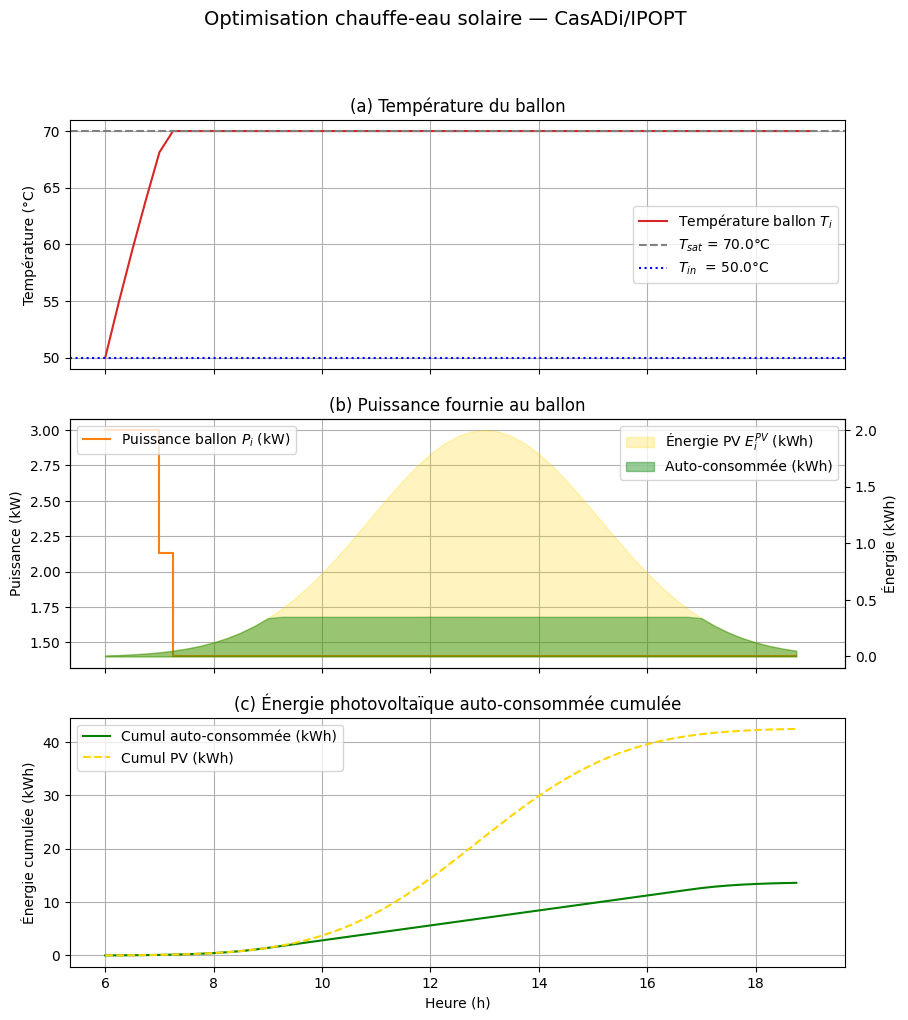


Énergie auto-consommée totale : 13.593 kWh
Énergie PV totale            : 42.404 kWh
Taux d'auto-consommation     : 32.1 %
T finale du ballon           : 70.00 °C


In [60]:
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca

# données de l'énoncé 
k      = 0.2      # h^{-1}
T_sat  = 70.0     # °C
T_in   = 50.0     # °C
C      = 100.0    # C/Wh
P_M    = 3000.0   # W
Q_base = 3.0      # W  
alpha = 100

dt  = 0.25        # h
t0  = 6.0
tf  = 19.0
times = np.arange(t0, tf, dt)
N = len(times)


E_PV = 2e3 * np.exp(-(times - 13)**2 / 9)          # puissance PV (W)
Q    = np.where((times >= 12) & (times < 13), Q_base, 0.0)  # apport solaire thermique, Q non nul seulement quans t = 12 
w    = np.zeros(N)                                   # consommation non-pilotable (W)
lam = np.exp(-k * dt)   # e^{-k Δt}

def soft_min_h(x1, x2, alpha):   # fonction h de l'énoncé
    e1 = ca.exp(-alpha * x1)
    e2 = ca.exp(-alpha * x2)
    return (x1 * e1 + x2 * e2) / (e1 + e2)

def solve_ballon_solaire():
    P  = ca.SX.sym('P',  N)        # puissance de chauffe (W) > on crée un vecteur 'à optimiser' avec P à tous les temps 
    T  = ca.SX.sym('T',  N + 1)   # température du ballon (°C) > on crée de meme un vecteur 'à optimiser' avec T à tous les temps

    # NB : on ne connait pas encore les valeurs de P et T, mais on crée le vecteur associé  

    x = ca.vertcat(P, T) # vecteur à optimiser

    # Contraintes sur x  

    lbx = [0.0] * N + [0] * (N + 1) #   P ≥ 0 W  et  T>=0
    ubx = [P_M]  * N + [T_sat] * (N + 1) #   P <= P_max W  et  T < T_sat

    E_hat = E_PV - w   # surplus PV disponible cf question 1. 

    # fonction à minimiser (h dans l'énoncé)
    cost = 0
    for i in range(N):
        p_energy = P[i] * dt
        cost -= soft_min_h(E_hat[i], p_energy, alpha)

    #Contraintes sur 
    g    = []
    lbg  = []
    ubg  = []

    g.append(T[0])
    lbg.append(T_in)
    ubg.append(T_in)

    # Dynamique 
    for i in range(N):
        g.append(T[i + 1] - lam * T[i] - (1 - lam) * (-Q[i] + P[i])/ (k*C))
        lbg.append(0.0)    # on impose que l'expression ci dessus soit == 0, soit que T[i+1] vérifie l'éq se l'énoncé
        ubg.append(0.0)

    g_vec = ca.vertcat(*g)


    nlp = {'x': x, 'f': cost, 'g': g_vec}  # var, fonciton à opt, contraintes
    solver = ca.nlpsol('solver', 'ipopt', nlp)

    # ← point initial non nul
    
    P_init = np.ones(N) * P_M
    x0 = np.concatenate([P_init, T_in * np.ones(N + 1)])

    sol = solver(
        x0=x0,
        lbx=lbx,
        ubx=ubx,
        lbg=lbg,
        ubg=ubg,
    )

    P_opt = np.array(sol['x'][:N]).flatten()
    T_opt = np.array(sol['x'][N:]).flatten()

    return P_opt, T_opt


P_opt, T_opt = solve_ballon_solaire()
E_hat     = E_PV - w
P_energy  = P_opt * dt
autoconso = np.minimum(E_hat, P_energy)   # vraie valeur (pas approchée)

#  Graphiques 
fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
fig.suptitle("Optimisation chauffe-eau solaire — CasADi/IPOPT", fontsize=14)

# (a) Température du ballon
ax = axes[0]
ax.plot(np.append(times, tf), T_opt, color='tab:red', label='Température ballon $T_i$')
ax.axhline(T_sat, color='gray', linestyle='--', label=f'$T_{{sat}}$ = {T_sat}°C')
ax.axhline(T_in,  color='blue', linestyle=':',  label=f'$T_{{in}}$  = {T_in}°C')
ax.set_ylabel('Température (°C)')
ax.set_title('(a) Température du ballon')
ax.legend()
ax.grid(True)

# (b) Puissance + énergie PV + énergie auto-consommée
ax = axes[1]
ax.step(times, P_opt / 1000, where='post', color='tab:orange',
        label='Puissance ballon $P_i$ (kW)')
ax.set_ylabel('Puissance (kW)')
ax.set_title('(b) Puissance fournie au ballon')
ax.legend(loc='upper left')
ax.grid(True)

ax2 = axes[1].twinx()
ax2.fill_between(times, E_PV / 1000,     alpha=0.25, color='gold',
                 label='Énergie PV $E_i^{PV}$ (kWh)')
ax2.fill_between(times, autoconso / 1000, alpha=0.4,  color='green',
                 label='Auto-consommée (kWh)')
ax2.set_ylabel('Énergie (kWh)')
ax2.legend(loc='upper right')

# (c) Cumul énergie auto-consommée
ax = axes[2]
ax.plot(times, np.cumsum(autoconso) / 1000, color='green',
        label='Cumul auto-consommée (kWh)')
ax.plot(times, np.cumsum(E_PV) / 1000,     color='gold', linestyle='--',
        label='Cumul PV (kWh)')
ax.set_xlabel('Heure (h)')
ax.set_ylabel('Énergie cumulée (kWh)')
ax.set_title('(c) Énergie photovoltaïque auto-consommée cumulée')
ax.legend()
ax.grid(True)

plt.show()

print(f"\nÉnergie auto-consommée totale : {np.sum(autoconso)/1000:.3f} kWh")
print(f"Énergie PV totale            : {np.sum(E_PV)/1000:.3f} kWh")
print(f"Taux d'auto-consommation     : {100*np.sum(autoconso)/np.sum(E_PV):.1f} %")
print(f"T finale du ballon           : {T_opt[-1]:.2f} °C")

### Interprétation : 

Les résultats obtenus sont cohérents avec une "journée type". En effet, le maximum d'énergie PV captée se trouve aux alentours de 12h.14h, soit quand le Soleil est au zénith et que les panneaux reçoivent le plus de rayons. 



7. On se propose d’introduire $N +1$ variables additionnelles si, telles que $s_i ≤ E^{PV}_i$, et $s_i ≤ P_i$  $i =0,...,N$. Reformuler le problème d’optimisation à l’aide de ces variables

On cherche toujours à maximimser l'énergie auto-consommée, donc à minimiser l'opposé de la fonction associée. 
On a désormais $3N + 1$ variables, et on remarque que cela signifie que $s_i$​ est un
minorant de  $ \min \{E_i^{PV}, P_i \Delta t\}$. 

En maximisant $\sum s_i$, on force $s_i \to \min\{E_i^{PV}, P_i \Delta t\}$ à l'optimum.

Les conditions restent les mêmes que formulées précédemment, avec en plus l'ajout des contraintes sur $s_i$. 


**Contraintes d'égalité** $c_{eq}$ :

$$T_{i+1} - e^{-\Delta t/C}T_i - \frac{(1-e^{-\Delta t/C})}{k}(C Q_i + P_i) = 0, \quad i = 0, \ldots, N-1$$

**Contraintes d'inégalité** $c_{in}$ :
$$s_i ≤ E^{PV}_i$$

$$s_i ≤ P_i$$


On a encore les anciennes contraintes :
$$-P_i \leq 0$$

$$P_i - P_M \leq 0$$

$$-T_i + T_{min} \leq 0$$

$$T_i - T_{set} \leq 0$$

8. Etudier la convexité de ce nouveau problème. Appartient-il à une famille particulière de problème
d’optimisation? Quels avantages/inconvénients présente-t-il par rapport à la formulation précédente ? 

Convexité : Le problème est désormais linéaire et les contraintes aussi, donc le problème est bien convexe. 

Avantages : tout est linéaire. Le problème est désormais convexe : par un théorème du cours, on sait désormais que tout minimum que l'on trouvera est un minimum global et non seulement local. 

Inconvénient : on a désormais 3N + 1 variables, le temps de calcul sera donc plus important. 

9. Résoudre ce nouveau problème avec les mêmes paramètres que précédemment. Comparer les solutions obtenues.

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      157
Number of nonzeros in inequality constraint Jacobian.:      156
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      157
                     variables with only lower bounds:       52
                variables with lower and upper bounds:      105
                     variables with only upper bounds:        0
Total number of equality constraints.................:       53
Total number of inequality constraints...............:      104
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:      104

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -5.2000000e+03 3.66e+04 1.02e-02  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

C:\Users\marie\AppData\Local\Temp\ipykernel_27432\435067336.py:109: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right')


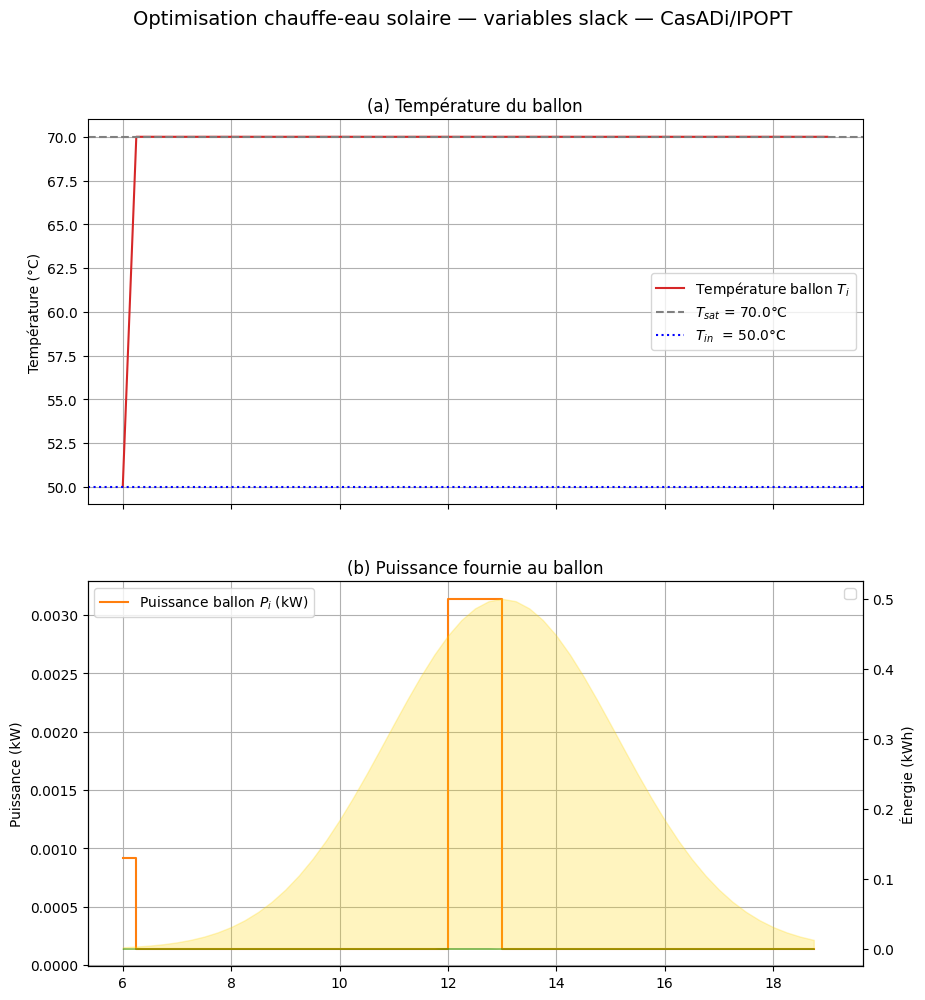

In [75]:
def solve_ballon_slack():
    P = ca.SX.sym('P', N)        # puissance de chauffe (W)
    T = ca.SX.sym('T', N + 1)   # température du ballon (°C)
    s = ca.SX.sym('s', N)        # variables slack (Wh)
 
    x = ca.vertcat(P, T, s)
 
 #Bornes 
    lbx = [0.0]     * N       \
        + [0.0] * (N + 1) \
        + [0.0]     * N        # s_i >= 0
 
    ubx = [P_M]    * N       \
        + [T_sat] * (N + 1) \
        + [ca.inf] * N
 
    cost = - ca.sum1(s)
 
 # Contraintes
    g   = []
    lbg = []
    ubg = []
 
    g.append(T[0])
    lbg.append(T_in)
    ubg.append(T_in)
 
    # Dynamique comme dans q6
    
    for i in range(N):
        g.append(T[i + 1] - lam * T[i] - (1 - lam) * C*(-Q[i] + P[i])/ k)
        lbg.append(0.0)
        ubg.append(0.0)
 
    # 4. s_i ≤ E_i^PV  (surplus PV disponible)
    E_hat = (E_PV - w) * dt   

    for i in range(N):
    # s[i] <= E_hat[i]  (valeur numérique connue, pas symbolique)
        g.append(s[i])
        lbg.append(-ca.inf)
        ubg.append(float(E_hat[i]))

        # s[i] <= P[i] * dt  (expression symbolique : OK pour CasADi)
        g.append(s[i] - P[i] * dt)
        lbg.append(-ca.inf)
        ubg.append(0.0)

    g_vec = ca.vertcat(*g)
 
    nlp = {'x': x, 'f': cost, 'g': g_vec}
    solver = ca.nlpsol('solver', 'ipopt', nlp)
 
    x0 = np.concatenate([
        np.ones(N) * P_M / 2,    # ← P initiale non nulle
        T_in * np.ones(N + 1),
        np.ones(N) * 100    
        ])
 
    sol = solver(
        x0=x0,
        lbx=lbx,
        ubx=ubx,
        lbg=lbg,
        ubg=ubg,
    )
 
    P_opt = np.array(sol['x'][:N]).flatten()
    T_opt = np.array(sol['x'][N:2 * N + 1]).flatten()
    s_opt = np.array(sol['x'][2 * N + 1:]).flatten()

    return P_opt, T_opt, s_opt
 
 
P_opt, T_opt, s_opt = solve_ballon_slack()
 
E_hat     = (E_PV - w)*dt
P_energy  = P_opt * dt
E_autoconso = s_opt
autoconso = np.minimum(E_hat, P_energy)   # vérification : doit coïncider avec s_opt
 
#  Graphiques 
fig, axes = plt.subplots(2, 1, figsize=(10, 11), sharex=True)
fig.suptitle("Optimisation chauffe-eau solaire — variables slack — CasADi/IPOPT",
             fontsize=14)
 
# (a) Température du ballon
ax = axes[0]
ax.plot(np.append(times, tf), T_opt, color='tab:red',
        label='Température ballon $T_i$')
ax.axhline(T_sat, color='gray',  linestyle='--', label=f'$T_{{sat}}$ = {T_sat}°C')
ax.axhline(T_in,  color='blue',  linestyle=':',  label=f'$T_{{in}}$  = {T_in}°C')
ax.set_ylabel('Température (°C)')
ax.set_title('(a) Température du ballon')
ax.legend()
ax.grid(True)
 
# (b) Puissance + énergie PV + s_i
ax = axes[1]
ax.step(times, P_opt / 1000, where='post', color='tab:orange',
        label='Puissance ballon $P_i$ (kW)')
ax.set_ylabel('Puissance (kW)')
ax.set_title('(b) Puissance fournie au ballon')
ax.legend(loc='upper left')
ax.grid(True)
 
ax2 = axes[1].twinx()

ax2.legend(loc='upper right')

ax2.fill_between(times, (E_PV - w) * dt / 1000, alpha=0.25, color='gold',
                 label='Énergie PV $E_i^{PV}$ (kWh)')
ax2.fill_between(times, s_opt / 1000, alpha=0.4, color='green',
                 label='Slack $s_i$ auto-consommée (kWh)')
ax2.set_ylabel('Énergie (kWh)')

print(f"Énergie auto-consommée totale (∑ s_i) : {np.sum(s_opt)/1000:.3f} kWh")
print(f"Énergie PV totale                      : {np.sum(E_PV*dt)/1000:.3f} kWh")
print(f"Taux d'auto-consommation               : {100*np.sum(s_opt)/np.sum(E_PV*dt):.1f} %")

# IV. Pilotage d’usages blancs et introduction à l’optimisation entière

10. On suppose dans un premier temps que le cycle de la machine à laver est lancée à un temps $t_{i0}$ 
fixe
donné. Ecrire le problème d’optimisation correspondant.

Ici, $t_{i0}$ est fixé. Ainsi, on doit prendre en compte la puissance pour $t_{i0} < t < t_{i0} + T$.
On veut toujours maximiser l'auto consommation, donc minorer son opposé. 

Et, 
$$ f(x)
= \sum_{i=1}^{N} \frac{x_1 e^{-\alpha x_1} + x_2 e^{-\alpha x_2}}{e^{-\alpha x_1} + e^{-\alpha x_2}}$$

avec $x = (x_1, x_2) = (E^{PV}_i, P_i \Delta t)$. 

ou encore 

$$f(x) = - \sum_{i=0}^{N-1} \min \{ E_i^{PV}, w_i + (P_i + P_i^L) \Delta t \}$$


####  Contraintes d'inégalité ($c_{in}$)
Comme d'habitude, le système est limité par les contraintes physiques de sécurité et de puissance

**Température du ballon** : $T_i - T_{sat} \le 0$ et $-T_i \le 0$ pour $i = 0, \dots, N$

**Puissance du chauffe-eau** : $P_i - P_M \le 0$ et $-P_i - \le 0$ pour $i = 0, \dots, N-1$

Notons que $P_L$ n'intervient pas dans les contraintes. En effet, c'est un coût fixe, qu'on ne peut optimiser. La seule chose que l'on peut changer est le moment auquel on lance la machine, mais pas sa valeur qui, lorsqu'on fait la somme, sera toujours la même.



11. A l’aide de ce sous-problème, proposer une approche combinatoire exhaustive permettant de résoudre
le problème originel. L’implémenter avec les mêmes paramètres que précédemment ainsi que $n_L= 6$
et $P^L =0.25W$. Commenter le résultat obtenu. Etudier l’extensibilité de cette technique de résolution
au cas de plusieurs autres usages pilotables

Une approche combinatoire exhaustive en optimisation consiste à énumérer et évaluer toutes les combinaisons possibles de solutions pour trouver la meilleure. Cela permet de manière sûre de trouver l'optimum, mais est très long et explose exponentiellement avec le nombre de variables. 

Nous allons donc essayer d'implémenter cette méthode pour pouvoir chercher à maximiser l'auto-consommation, ie à minimiser son opposé. 

On va pour cela essayer de voir à quel moment il est préférable de lancer la machine. Pour cela, on teste tous les instants de $ t = 0$ à $ t = Tf - n_L$, on construit les vecteurs et la solution, puis on compare ensuite pour prendre celui qui maximise la somme. 

Autrement dit, pour chaque i0 possible :
    - on fixer P_L (la machine à laver est un paramètre, pas une variable)
    - puis on optimisep P (le ballon) comme dans les questions précédentes
On compare ensuitre tous les taux d'autoconsommation pour garder le meilleur i0. 

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      157
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        6

Error evaluating objective gradient at user provided starting point.
  No scaling factor for objective function computed!

Number of Iterations....: 0

Number of objective function evaluations             = 0
Number of objective gradient evaluations             = 1
Number of equality constraint evaluations            = 0
Number of inequality constraint evaluations          = 0
Number of equality constraint Jacobian evaluations   = 1
Number of inequality constraint Jacobian evaluations = 0
Number of Lagrangian Hessian evaluations             = 0
Total seconds in IPOPT                               = 0.002

EXIT: Invalid number in NLP function or derivative detected.
      solver  :   t_proc      (avg)   t_wall      (avg)    n_

CasADi - 2026-04-21 22:42:08 WARNING("solver:nlp_grad_f failed: NaN detected for output grad_f_x, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-04-21 22:42:08 WARNING("solver:nlp_grad_f failed: NaN detected for output grad_f_x, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-04-21 22:42:09 WARNING("solver:nlp_grad_f failed: NaN detected for output grad_f_x, at (row 1, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-04-21 22:42:09 WARNING("solver:nlp_grad_f failed: NaN detected for output grad_f_x, at (row 1, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-04-21 22:42:09 WARNING("solver:nlp_grad_f failed: NaN detected for output grad_f_x, at (row 2, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-04-21 22:42:09 WARNING("solver:nlp_grad_f failed: NaN detected for output grad_f_x, at (row 2, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-04-21 22:42:09 WARNI

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      157
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        3

Error evaluating objective gradient at user provided starting point.
  No scaling factor for objective function computed!

Number of Iterations....: 0

Number of objective function evaluations             = 0
Number of objective gradient evaluations             = 1
Number of equality constraint evaluations            = 0
Number of inequality constraint evaluations          = 0
Number of equality constraint Jacobian evaluations   = 1
Number of inequality constraint Jacobian evaluations = 0
Number of Lagrangian Hessian evaluations             = 0
Total seconds in IPOPT                               = 0.003

EXIT: Invalid number in NLP function or derivative detected.
      solver  :   t_proc      (avg)   t_wall      (avg)    n_

CasADi - 2026-04-21 22:42:09 WARNING("solver:nlp_grad_f failed: NaN detected for output grad_f_x, at (row 4, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-04-21 22:42:09 WARNING("solver:nlp_grad_f failed: NaN detected for output grad_f_x, at (row 4, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-04-21 22:42:09 WARNING("solver:nlp_grad_f failed: NaN detected for output grad_f_x, at (row 5, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-04-21 22:42:09 WARNING("solver:nlp_grad_f failed: NaN detected for output grad_f_x, at (row 5, col 0).") [.../casadi/core/oracle_function.cpp:408]


   1 -1.9281974e+00 4.27e+01 9.26e+01  -1.0 5.37e+01    -  4.56e-03 4.33e-01f  1
   2 -4.2986209e+00 1.24e-14 6.27e-01  -1.0 1.76e+00    -  4.13e-01 1.00e+00h  1
   3 -4.3063826e+00 9.33e-15 1.39e-02  -1.0 8.10e-01    -  9.78e-01 1.00e+00f  1
   4 -4.3587793e+00 1.07e-14 3.32e-03  -1.0 6.70e+00    -  9.92e-01 1.00e+00f  1
   5 -4.4236694e+00 1.15e-14 4.44e-02  -1.7 4.77e+00    -  9.50e-01 1.00e+00f  1
   6 -4.6163859e+00 1.44e-14 5.02e-02  -2.5 1.02e+01    -  7.80e-01 1.00e+00f  1
   7 -4.8476441e+00 1.29e-14 3.74e-03  -2.5 2.93e+01    -  8.94e-01 1.00e+00f  1
   8 -4.9559546e+00 2.09e-14 1.59e-03  -3.8 1.57e+01    -  8.16e-01 7.40e-01f  1
   9 -5.0022682e+00 1.82e-14 8.34e-04  -3.8 3.35e+00    -  1.00e+00 9.20e-01f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  10 -5.0141042e+00 1.78e-14 6.41e-05  -5.7 1.05e+00    -  9.21e-01 9.44e-01f  1
  11 -5.0149406e+00 2.18e-14 1.57e-06  -5.7 1.55e-01    -  9.97e-01 9.94e-01f  1
  12 -5.0150416e+00 2.31e-14

CasADi - 2026-04-21 22:42:12 WARNING("solver:nlp_grad_f failed: NaN detected for output grad_f_x, at (row 51, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-04-21 22:42:12 WARNING("solver:nlp_grad_f failed: NaN detected for output grad_f_x, at (row 51, col 0).") [.../casadi/core/oracle_function.cpp:408]


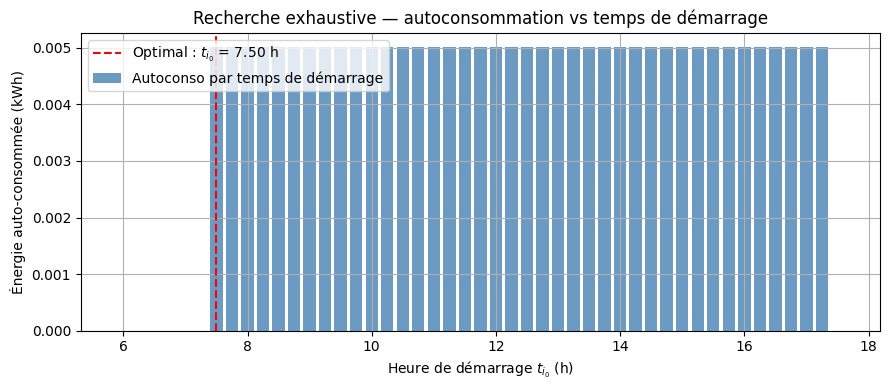

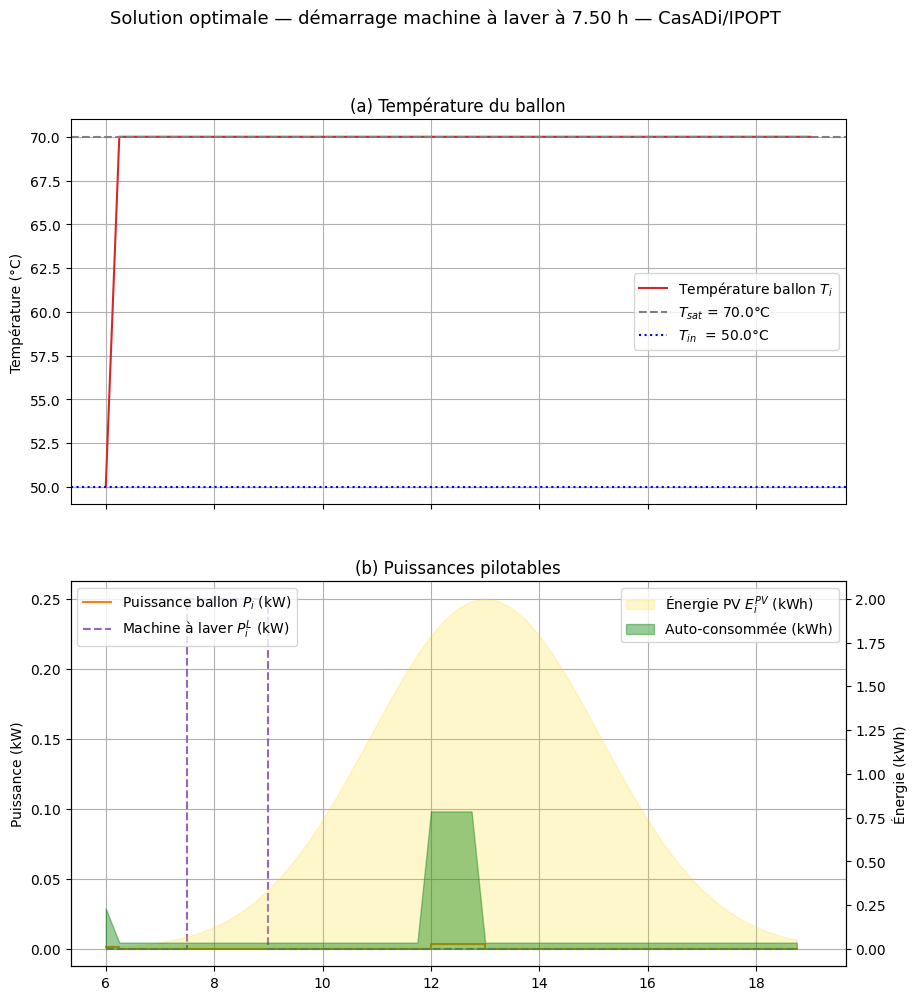


Énergie auto-consommée totale : 5.0150 kWh
Énergie PV totale             : 42403.5317 kWh
T finale du ballon            : 70.00 °C


In [67]:
n_L   = 6        # durée du cycle en nombre de pas
P_bar = 250.0    # W

E_PV = 2e3 * np.exp(-(times - 13)**2 / 9)
Q    = np.where((times >= 12) & (times < 13), Q_base, 0.0)
w    = np.zeros(N)

lam = np.exp(-k * dt)


def compute_P_L(i0, n_L, P_bar):
    P_L = np.zeros(N)
    for j in range(i0, min(i0 + n_L, N)):
        P_L[j] = P_bar
    return P_L

def soft_min_h(x1, x2, alpha):   # fonction h de l'énoncé
    e1 = ca.exp(-alpha * x1)
    e2 = ca.exp(-alpha * x2)
    return (x1 * e1 + x2 * e2) / (e1 + e2)

def solve_ballon_with_washer(P_L):
    P = ca.SX.sym('P', N)
    T = ca.SX.sym('T', N + 1)

    x = ca.vertcat(P, T)

    lbx = [0.0]     * N + [0] * (N + 1)
    ubx = [P_M]     * N + [T_sat]  * (N + 1)

    E_hat = E_PV - w - P_L * dt   # changmeent par rapport à d'habitude : on soustrait la puissance PL 

    cost = 0
    for i in range(N):
        p_energy = P[i] * dt
        cost -=  soft_min_h(E_hat[i], p_energy, alpha)
    
    # contraintes
    g   = []
    lbg = []
    ubg = []

    g.append(T[0])
    lbg.append(T_in)
    ubg.append(T_in)

    for i in range(N):
        g.append(T[i + 1] - lam * T[i] - (1 - lam) * (-Q[i] + P[i]) *C / k)
        lbg.append(0.0)
        ubg.append(0.0)

    g_vec = ca.vertcat(*g)

    nlp  = {'x': x, 'f': cost, 'g': g_vec}
    solver = ca.nlpsol('solver', 'ipopt', nlp)

    x0 = np.concatenate([np.zeros(N), T_in * np.ones(N + 1)])

    sol = solver(x0=x0, lbx=lbx, ubx=ubx, lbg=lbg, ubg=ubg)

    P_opt = np.array(sol['x'][:N]).flatten()
    T_opt = np.array(sol['x'][N:]).flatten()
    obj   = float(sol['f'])

    return P_opt, T_opt, obj


valid_starts = range(0, N - n_L + 1)

best_obj   = -np.inf
best_i0    = None
best_P_opt = None
best_T_opt = None
best_P_L   = None

results = []

for i0 in valid_starts:
    P_L = compute_P_L(i0, n_L, P_bar)
    P_opt, T_opt, obj = solve_ballon_with_washer(P_L)
    autoconso_total = -obj
    results.append((i0, autoconso_total))

    if autoconso_total > best_obj:
        best_obj   = autoconso_total
        best_i0    = i0
        best_P_opt = P_opt.copy()
        best_T_opt = T_opt.copy()
        best_P_L   = P_L.copy()

t_best = times[best_i0]
print(f"\n→ Meilleur démarrage : i0 = {best_i0}  (t = {t_best:.2f} h)")
print(f"  Énergie auto-consommée : {best_obj:.4f} kWh")

E_hat_best = E_PV - w - best_P_L * dt
autoconso  = np.minimum(E_hat_best, best_P_opt * dt)

#autoconsommation vs temps de démarrage 
i0_arr  = np.array([r[0] for r in results])
obj_arr = np.array([r[1] for r in results]) / 1000

fig0, ax0 = plt.subplots(figsize=(9, 4))
ax0.bar(times[i0_arr], obj_arr, width=dt * 0.8, color='steelblue', alpha=0.8,
        label='Autoconso par temps de démarrage')
ax0.axvline(t_best, color='red', linestyle='--',
            label=f'Optimal : $t_{{i_0}}$ = {t_best:.2f} h')
ax0.set_xlabel('Heure de démarrage $t_{i_0}$ (h)')
ax0.set_ylabel('Énergie auto-consommée (kWh)')
ax0.set_title('Recherche exhaustive — autoconsommation vs temps de démarrage')
ax0.legend()
ax0.grid(True)
plt.tight_layout()
plt.savefig('ballon_washer_exhaustive.png', dpi=150)

#  solution optimale 
fig, axes = plt.subplots(2, 1, figsize=(10, 11), sharex=True)
fig.suptitle(
    f"Solution optimale — démarrage machine à laver à {t_best:.2f} h — CasADi/IPOPT",
    fontsize=13)


# (a) Température
ax = axes[0]
ax.plot(np.append(times, tf), best_T_opt, color='tab:red',
        label='Température ballon $T_i$')
ax.axhline(T_sat, color='gray', linestyle='--', label=f'$T_{{sat}}$ = {T_sat}°C')
ax.axhline(T_in,  color='blue', linestyle=':',  label=f'$T_{{in}}$  = {T_in}°C')
ax.set_ylabel('Température (°C)')
ax.set_title('(a) Température du ballon')
ax.legend(); ax.grid(True)

# (b) Puissances
ax = axes[1]
ax.step(times, best_P_opt / 1000, where='post', color='tab:orange',
        label='Puissance ballon $P_i$ (kW)')
ax.step(times, best_P_L   / 1000, where='post', color='tab:purple', linestyle='--',
        label='Machine à laver $P^L_i$ (kW)')
ax.set_ylabel('Puissance (kW)')
ax.set_title('(b) Puissances pilotables')
ax.legend(loc='upper left'); ax.grid(True)

ax2 = axes[1].twinx()
ax2.fill_between(times, E_PV / 1000,       alpha=0.20, color='gold',
                 label='Énergie PV $E_i^{PV}$ (kWh)')
ax2.fill_between(times, autoconso,  alpha=0.40, color='green',
                 label='Auto-consommée (kWh)')
ax2.set_ylabel('Énergie (kWh)')
ax2.legend(loc='upper right')

plt.show()

print(f"\nÉnergie auto-consommée totale : {best_obj:.4f} kWh")
print(f"Énergie PV totale             : {np.sum(E_PV):.4f} kWh")
print(f"T finale du ballon            : {best_T_opt[-1]:.2f} °C")

L'extensibilité de cette technique est limitée. En effet, à chaque ajout d'un nouvel appareil, on observe une croissance exponentielle du nombre de calculs à faire, et donc du temps de computation. 
